## CONTEXTO

**Barreras a la Formación (EAL-24)** y **Motivos de No Formación (EAL-25)**

### Resumen de Tablas: Análisis de Barreras y Limitaciones

| Código de Tabla | Descripción del Contenido | Relevancia para el Proyecto |
| :--- | :--- | :--- |
| **EAL-24** | **Barreras Generales:** Grado de limitación (nada a mucho) de 10 motivos específicos en empresas que **SÍ** proporcionaron formación. | Proporciona la línea base nacional para entender qué dificultades encuentran las empresas al intentar formar. |
| **EAL-24c** | **Barreras en Grandes Empresas:** Mismo desglose que la EAL-24 pero exclusivo para empresas de **más de 499 trabajadores**. | **Es la tabla prioritaria.** Al ser RapidExpress una gran empresa, estos datos reflejan sus retos específicos (ej. carga de trabajo). |
| **EAL-24f** | **Barreras en el Sector Servicios:** Limitaciones detectadas específicamente en las empresas de servicios que sí forman. | Permite contrastar si las barreras de nuestro sector (Transporte) son más agudas que en el resto de servicios. |
| **EAL-25** | **Motivos de No Formación:** Grado de influencia de factores que llevaron a la decisión de **NO** proporcionar formación. | Útil para identificar por qué otras empresas del mercado deciden no invertir en el desarrollo de su personal. |
| **EAL-25b** | **Inacción en Medianas/Grandes Empresas:** Motivos de no formación en empresas de **50 o más trabajadores**. | Se utiliza como **referencia (proxy)** para entender las razones estratégicas o logísticas de inacción en organizaciones de mayor tamaño. |
| **EAL-25e** | **No Formación en Servicios:** Razones de peso por las que el sector servicios decide no realizar acciones formativas. | Ayuda a diagnosticar si en nuestro entorno la falta de formación se debe a una "decisión estratégica" o a "barreras reales". |


**Nota Metodológica:** Todas las comparaciones entre porcentajes de estas tablas (especialmente entre **EAL-24c** y el resto) serán validadas mediante **tests de diferencias de proporciones (Z-test)** para asegurar que los hallazgos sean estadísticamente significativos

## 1. Fase de EDA Simple (Dataset 2024)
Antes de filtrar, realizamos una exploración general de las barreras en el sector servicios y el segmento de grandes empresas:

### 1. Fase de EDA y Consistencia (Dataset 2020-2024)
*   **Mantenimiento del Top-2-Box:** Seguirás utilizando la columna **RELEVANCIA** (Bastante + Mucho) para simplificar la comparación.
*   **Tratamiento de Inconsistencias (Mapeo):** Dado que el número de respuestas cambió entre 2020 y 2021, antes de filtrar debes asegurar que las categorías de barreras sean las mismas en toda la serie [Conversación anterior].
*   **Visualización de Estabilidad:** En lugar de solo barras para 2024, genera un gráfico de líneas que muestre la **evolución de la relevancia** de las 10 barreras año a año para detectar visualmente picos o caídas bruscas.

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

In [142]:
df_barreras= pd.read_csv('../../Data/clean/EAL_15062025/limitaciones.csv')

In [143]:
df_barreras

,anio,tabla,proporcionaron_formacion,pregunta,ambito,NADA,POCO,BASTANTE,MUCHO
0,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,El nivel de formación de los empleados era el ...,10.031,13.505,60.232,16.232
1,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,La estrategia preferida de la empresa fue cont...,32.843,22.364,35.637,9.155
2,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,Dificultad para evaluar la necesidades de form...,37.356,45.367,15.583,1.694
3,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,La falta de cursos de formación adecuados en e...,31.751,39.726,21.844,6.679
4,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,El alto coste de los cursos de formación,24.188,36.048,29.953,9.811
...,...,...,...,...,...,...,...,...,...
277,2024,EAL-25e,No,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,La empresa prefirió tener personal con contrat...,70.067,19.881,8.260,1.792
278,2024,EAL-25e,No,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,El mayor esfuerzo realizado en años anteriores...,44.018,34.269,17.211,4.502
279,2024,EAL-25e,No,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,La elevada carga de trabajo y el escaso tiempo...,22.419,29.643,30.416,17.522
280,2024,EAL-25e,No,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,Dificultad para acceder a ayudas o subvencione...,36.200,30.566,20.535,12.699


In [144]:
df_barreras.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282 entries, 0 to 281
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   anio                      282 non-null    int64  
 1   tabla                     282 non-null    object 
 2   proporcionaron_formacion  282 non-null    object 
 3   pregunta                  282 non-null    object 
 4   ambito                    282 non-null    object 
 5   NADA                      282 non-null    float64
 6   POCO                      282 non-null    float64
 7   BASTANTE                  282 non-null    float64
 8   MUCHO                     282 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 20.0+ KB


In [145]:
df_barreras.shape

(282, 9)

In [146]:
df_barreras.describe().round(2)

,anio,NADA,POCO,BASTANTE,MUCHO
count,282.00,282.00,282.00,282.00,282.00
mean,2022.10,31.23,33.82,26.01,8.94
std,1.39,15.81,11.44,13.12,6.89
min,2020.00,6.46,6.87,4.22,0.17
25%,2021.00,20.32,25.87,16.90,3.19
50%,2022.00,28.56,34.36,23.23,7.00
75%,2023.00,37.28,42.39,34.99,12.51
max,2024.00,72.63,58.05,61.08,33.58


La mayoría de las barreras son percibidas como poco o nada importantes, aunque algunas destacan claramente sobre el resto y llegan a ser consideradas obstáculos relevantes por una proporción significativa de empresas.

In [147]:
df_barreras.columns

Index(['anio', 'tabla', 'proporcionaron_formacion', 'pregunta', 'ambito',
       'NADA', 'POCO', 'BASTANTE', 'MUCHO'],
      dtype='object')

### **Distribución de frecuencias:** 

Generamos tablas de frecuencias para las respuestas "Bastante" y "Mucho" de las tablas **EAL-24c** (>499 trabajadores) y **EAL-25b** (>=50 trabajadores).

Primero creamos columna RELEVANCIA

In [148]:
df_relevancia=df_barreras.copy()

In [149]:
df_relevancia

,anio,tabla,proporcionaron_formacion,pregunta,ambito,NADA,POCO,BASTANTE,MUCHO
0,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,El nivel de formación de los empleados era el ...,10.031,13.505,60.232,16.232
1,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,La estrategia preferida de la empresa fue cont...,32.843,22.364,35.637,9.155
2,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,Dificultad para evaluar la necesidades de form...,37.356,45.367,15.583,1.694
3,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,La falta de cursos de formación adecuados en e...,31.751,39.726,21.844,6.679
4,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,El alto coste de los cursos de formación,24.188,36.048,29.953,9.811
...,...,...,...,...,...,...,...,...,...
277,2024,EAL-25e,No,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,La empresa prefirió tener personal con contrat...,70.067,19.881,8.260,1.792
278,2024,EAL-25e,No,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,El mayor esfuerzo realizado en años anteriores...,44.018,34.269,17.211,4.502
279,2024,EAL-25e,No,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,La elevada carga de trabajo y el escaso tiempo...,22.419,29.643,30.416,17.522
280,2024,EAL-25e,No,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,Dificultad para acceder a ayudas o subvencione...,36.200,30.566,20.535,12.699


In [150]:
mapa_nombres = {
    # --- 1. Contratación Externa  ---
    "La empresa prefirió contratar a personal con la cualificación, habilidades y competencias necesarias": "Contratación externa",
    "La estrategia preferida de la empresa fue contratar personal con la cualificación, habilidades o competencias requeridas": "Contratación externa",

    # --- 2. Formación Dual / Contratos ---
    "La empresa prefirió tener personal con contratos formativos o personal en formación por convenio de Formación profesional dual a proporcionar más formación a sus trabajadores": "Contratos formación/Dual",
    "La empresa prefirió tener personal con contrato de formación y aprendizaje o formación por convenio de formación profesional dual": "Contratos formación/Dual",
    "La empresa prefirió tener personal con contratos formativos": "Contratos formación/Dual",

    # --- 3. Carga de Trabajo  ---
    "La elevada carga de trabajo y el escaso tiempo disponible de los empleados de su empresa": "Carga trabajo / Falta tiempo",
    "La elevada carga de trabajo y el escaso tiempo disponible de los trabajadores de la empresa": "Carga trabajo / Falta tiempo",

    # --- 4. Nivel Formativo ---
    "El nivel de formación de los empleados era el apropiado para las necesidades de la empresa": "Nivel formación adecuado",
    "El nivel de cualificación, habilidades y competencias de los trabajadores era el adecuado para las necesidades de la empresa": "Nivel formación adecuado",

    # --- 5. Otras Razones ---
    "Otras razones": "Otras razones",

    # --- Resto de barreras (Estructura constante 2020-2024) ---
    "Cancelación o aplazamiento de las actividades de formación debido a las restricciones por COVID": "Restricciones COVID",
    "El alto coste de los cursos de formación": "Alto coste cursos",
    "Dificultad para acceder a ayudas o subvenciones públicas": "Dificultad ayudas públicas",
    "La falta de cursos de formación adecuados en el mercado": "Falta oferta adecuada",
    "El mayor esfuerzo realizado en años anteriores para ofrecer formación a sus trabajadores": "Esfuerzo años anteriores",
    "Dificultad para evaluar la necesidades de formación de la empresa": "Dificultad evaluar necesidades"
}

# 2. Aplicación con limpieza de espacios (TRIM) para evitar fallos de lectura
df_relevancia['ambito_corto'] = df_relevancia['ambito'].str.strip().map(mapa_nombres)

# 3. Verificación de limpieza
nan_count = df_relevancia['ambito_corto'].isna().sum()
if nan_count == 0:
    print("✅ ¡Conseguido! Todas las filas están mapeadas correctamente.")
else:
    print(f"⚠️ Aún quedan {nan_count} filas sin mapear.")
    print(df_relevancia[df_relevancia['ambito_corto'].isna()]['ambito'].unique())

✅ ¡Conseguido! Todas las filas están mapeadas correctamente.


In [151]:
# Creamos el índice de RELEVANCIA (Top-2-Box)
df_relevancia['RELEVANCIA'] = df_relevancia['BASTANTE'] + df_relevancia['MUCHO']

# Visualización rápida de la estructura
print(f"Dataset cargado: {df_relevancia.shape} filas.")
df_relevancia.head()


Dataset cargado: (282, 11) filas.


,anio,tabla,proporcionaron_formacion,pregunta,ambito,NADA,POCO,BASTANTE,MUCHO,ambito_corto,RELEVANCIA
0,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,El nivel de formación de los empleados era el ...,10.031,13.505,60.232,16.232,Nivel formación adecuado,76.464
1,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,La estrategia preferida de la empresa fue cont...,32.843,22.364,35.637,9.155,Contratación externa,44.792
2,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,Dificultad para evaluar la necesidades de form...,37.356,45.367,15.583,1.694,Dificultad evaluar necesidades,17.277
3,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,La falta de cursos de formación adecuados en e...,31.751,39.726,21.844,6.679,Falta oferta adecuada,28.523
4,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,El alto coste de los cursos de formación,24.188,36.048,29.953,9.811,Alto coste cursos,39.764


> Se aplicó la técnica **Top-2-Box**, que consiste en agrupar las respuestas **"Bastante"** y **"Mucho"** en un único indicador de **relevancia**. Esta transformación simplifica la interpretación de los resultados, facilita la elaboración de rankings y permite identificar rápidamente las barreras, competencias o necesidades formativas más importantes para las empresas. Además, mejora la comparabilidad entre sectores y hace más clara la visualización de los hallazgos para la toma de decisiones, convirtiéndose en un indicador clave para priorizar las acciones de RRHH.

#### Barreras grandes empresas formadoras (EAL-24c)

In [152]:
# 1. Empresas de >499 que SÍ proporcionaron formación (EAL-24c)
print("--- RELEVANCIA DE BARRERAS EN GRANDES EMPRESAS (>499) ---")
resumen_24c = df_relevancia[df_relevancia['tabla'] == 'EAL-24c'][['ambito_corto', 'RELEVANCIA', 'BASTANTE', 'MUCHO']].sort_values(by='RELEVANCIA', ascending=False)
print(resumen_24c)

--- RELEVANCIA DE BARRERAS EN GRANDES EMPRESAS (>499) ---
                       ambito_corto  RELEVANCIA  BASTANTE   MUCHO
62     Carga trabajo / Falta tiempo      55.277    42.644  12.633
119    Carga trabajo / Falta tiempo      55.056    41.209  13.847
82         Nivel formación adecuado      54.260    47.241   7.019
38     Carga trabajo / Falta tiempo      53.886    44.092   9.794
112        Nivel formación adecuado      53.291    47.697   5.594
89     Carga trabajo / Falta tiempo      50.298    38.271  12.027
56         Nivel formación adecuado      50.201    44.575   5.626
32         Nivel formación adecuado      49.110    44.621   4.489
14     Carga trabajo / Falta tiempo      46.454    36.550   9.904
8          Nivel formación adecuado      45.687    40.575   5.112
113            Contratación externa      37.747    31.742   6.005
83             Contratación externa      37.620    31.607   6.013
116               Alto coste cursos      37.570    30.667   6.903
57             Con

#### Barreras empresas no formadoras (EAL-25b)

In [153]:
# 2. Empresas de >=50 que NO proporcionaron formación (EAL-25b)
print("\n--- RELEVANCIA DE MOTIVOS PARA NO FORMAR (>=50 emp.) ---")
resumen_25b = df_relevancia[df_relevancia['tabla'] == 'EAL-25b'][['ambito_corto', 'RELEVANCIA', 'BASTANTE', 'MUCHO']].sort_values(by='RELEVANCIA', ascending=False)
print(resumen_25b)


--- RELEVANCIA DE MOTIVOS PARA NO FORMAR (>=50 emp.) ---
                       ambito_corto  RELEVANCIA  BASTANTE   MUCHO
232        Nivel formación adecuado      75.057    46.107  28.950
200        Nivel formación adecuado      74.792    56.511  18.281
262        Nivel formación adecuado      73.978    49.030  24.948
140        Nivel formación adecuado      67.250    44.806  22.444
167        Nivel formación adecuado      66.109    45.158  20.951
263            Contratación externa      62.547    41.856  20.691
201            Contratación externa      58.864    41.861  17.003
233            Contratación externa      54.353    35.177  19.176
168            Contratación externa      52.749    36.933  15.816
239    Carga trabajo / Falta tiempo      51.655    34.545  17.110
207    Carga trabajo / Falta tiempo      47.768    36.991  10.777
174    Carga trabajo / Falta tiempo      47.460    38.846   8.614
141            Contratación externa      43.771    27.328  16.443
146    Carga traba

#### **Visualizaciones iniciales:** 

Creamos diagramas de barras para identificar visualmente cuál es la barrera predominante.


/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_33476/3192984673.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=resumen_24c, x='RELEVANCIA', y='ambito_corto', palette='viridis')


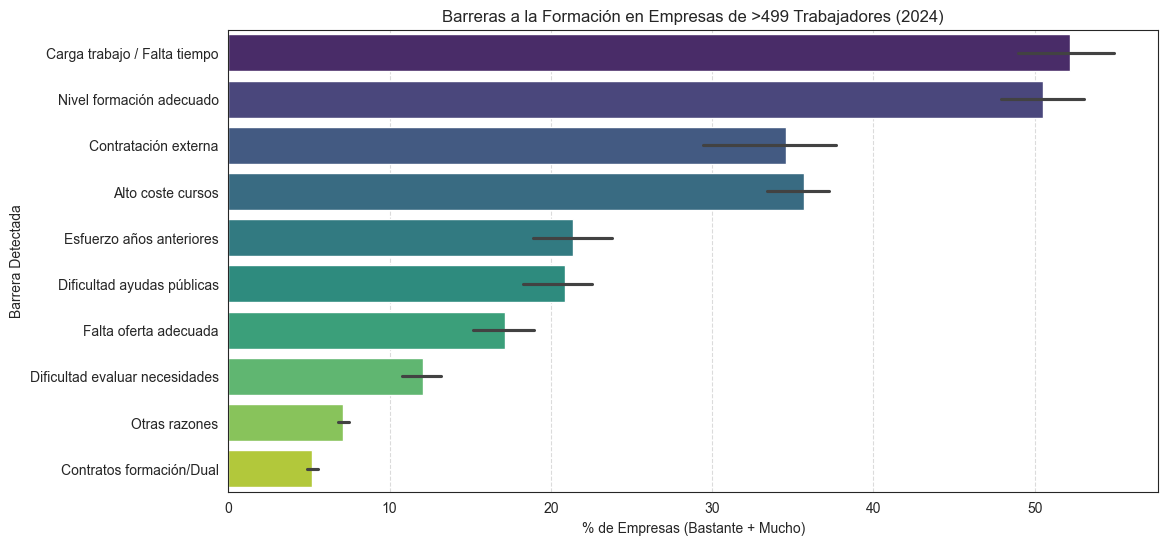

In [154]:
plt.figure(figsize=(12, 6), facecolor='none')
ax=sns.barplot(data=resumen_24c, x='RELEVANCIA', y='ambito_corto', palette='viridis')
ax.set_facecolor('none')
plt.title('Barreras a la Formación en Empresas de >499 Trabajadores (2024)')
plt.xlabel('% de Empresas (Bastante + Mucho)')
plt.ylabel('Barrera Detectada')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Confirmamos visualmente que la "elevada carga de trabajo y escaso tiempo" es el factor crítico en las grandes organizaciones que si dieron formación. Casi a la par, se el "nivel de formación apropiado a las necesidades" es otra barrera importante que encontraban las empresas formadoras.

/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_33476/1790641674.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=resumen_25b, x='RELEVANCIA', y='ambito_corto', palette='viridis')


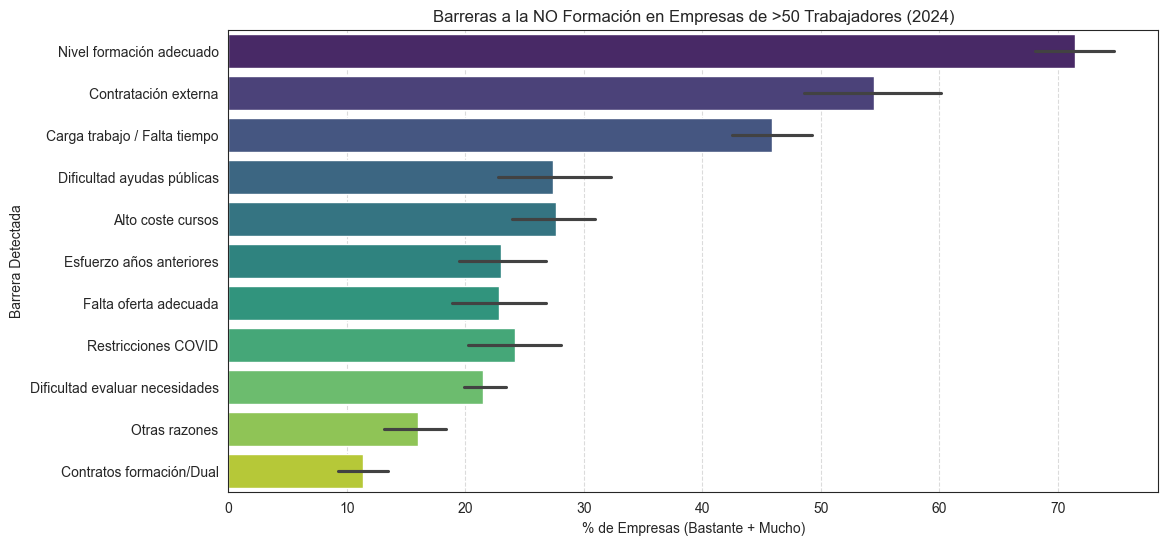

In [155]:
plt.figure(figsize=(12, 6), facecolor='none')
ax=sns.barplot(data=resumen_25b, x='RELEVANCIA', y='ambito_corto', palette='viridis')
ax.set_facecolor('none')
plt.title('Barreras a la NO Formación en Empresas de >50 Trabajadores (2024)')
plt.xlabel('% de Empresas (Bastante + Mucho)')
plt.ylabel('Barrera Detectada')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Motivos de inacción:

Las organizaciones que no dieron formación consideran como factor critico el "nivel de formación apropiado a las necesidades" (auto-suficiencia percibida) junto con la decisión de "contratar a personal cualificado" (contratación externa) en lugar de desarrollar talento interno

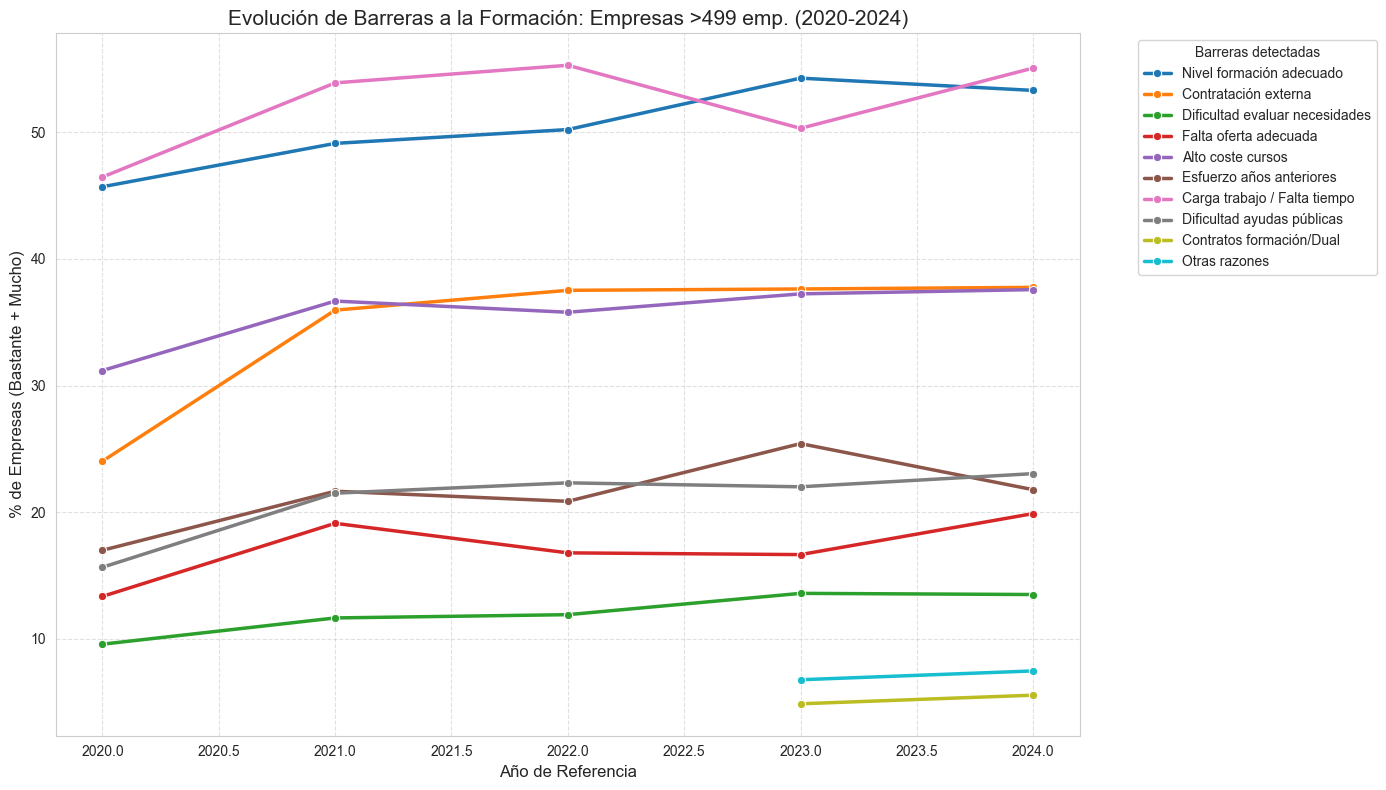

In [156]:
# 1. Filtramos por el segmento de grandes empresas que forman (EAL-24c)
df_lineas = df_relevancia[df_relevancia['tabla'] == 'EAL-24c'].copy()

# 2. Configuración del estilo y tamaño
plt.figure(figsize=(14, 8), facecolor='none')
sns.set_style("whitegrid")

# 3. Creación del gráfico de líneas
# Usamos RELEVANCIA (Top-2-Box: Bastante + Mucho)
ax = sns.lineplot(
    data=df_lineas, 
    x='anio', 
    y='RELEVANCIA', 
    hue='ambito_corto', 
    marker='o', 
    linewidth=2.5
)

ax.set_facecolor('none')

# 4. Personalización estética
plt.title('Evolución de Barreras a la Formación: Empresas >499 emp. (2020-2024)', fontsize=15)
plt.ylabel('% de Empresas (Bastante + Mucho)', fontsize=12)
plt.xlabel('Año de Referencia', fontsize=12)
plt.xticks() # Aseguramos que se vean todos los años
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Barreras detectadas')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 2. Agregación y Clasificación Estratégica (Dimensiones)
Mantendrás la agrupación de los 10 motivos en las tres macro-categorías definidas en la justificación técnica, pero con un enfoque en la **huella sectorial**:
*   **Factores de Tiempo/Organizativos:** (Motivos 8, 1 y 2). Es crítico observar si la "carga de trabajo" ha sido siempre la barrera número uno o si es un fenómeno reciente.
*   **Factores Económicos:** (Motivos 5 y 9).
*   **Factores de Oferta:** (Motivos 4 y 3).


### 3. Análisis de Tendencias mediante Variación Relativa
Siguiendo la instrucción de la superior, eliminarás la variación absoluta y aplicarás únicamente la **Variación Relativa** para identificar el ritmo de cambio [Conversación anterior]:
*   **Cálculo:** (Relevancia 2024 - Relevancia Año Base) / (Relevancia Año Base) * 100.
*   **Año Base Flexible:** Debido a las especificaciones de los datos, el año base no siempre será 2020. Por ejemplo, para los objetivos formativos (EAL-23), tu año base será **2021** [Conversación anterior].
*   **Objetivo:** Identificar qué barreras están creciendo más rápido porcentualmente, lo que indicará problemas emergentes para RapidExpress.


#### Preparación y Armonización (El "Año Base")
Hay cambios estructurales entre los años del df, es decir hay tablas que no existen o no son iguales en contenido en ciertos años. No podemos usar 2020 como año base para todo. Usaremos esta lógica:
- EAL-24 y 25: Si los ítems de 2020 no coinciden, usa 2021 como año base.
- EAL-23: Año base 2021 
- EAL-18b: Año base 2023 (solo hay dos años).

In [157]:
#Filtramos por el segmento RapidExpress (>499 y formación SI)
df_tendencia = df_relevancia[(df_relevancia['tabla'] == 'EAL-24c')].copy()

In [158]:
#Calculamos Variación Relativa (%) entre el primer año disponible y el último año
def calcular_var_relativa(group):
    group = group.sort_values('anio')

    val_inicial = group['RELEVANCIA'].iloc[0]
    val_final = group['RELEVANCIA'].iloc[-1]

    # Evitar división por cero
    if val_inicial == 0:
        return None

    #Variación relativa (%)
    return ((val_final - val_inicial) / val_inicial) * 100

In [159]:
resumen_tendencia = (
    df_tendencia
    .groupby('ambito')
    .apply(calcular_var_relativa)
    .reset_index(name='Variacion_Relativa_%')
)

#Ordenamos de mayor crecimiento a mayor caída
resumen_tendencia = resumen_tendencia.sort_values(
    by='Variacion_Relativa_%',
    ascending=False
)

print(resumen_tendencia)

                                               ambito  Variacion_Relativa_%
8   La estrategia preferida de la empresa fue cont...             56.145682
9   La falta de cursos de formación adecuados en e...             48.970423
0   Dificultad para acceder a ayudas o subvencione...             47.211753
1   Dificultad para evaluar la necesidades de form...             40.901503
3   El mayor esfuerzo realizado en años anteriores...             28.116726
2            El alto coste de los cursos de formación             20.486178
5   La elevada carga de trabajo y el escaso tiempo...             18.517243
4   El nivel de formación de los empleados era el ...             16.643684
7   La empresa prefirió tener personal con contrat...             13.934426
10                                      Otras razones             10.268516
6   La empresa prefirió contratar a personal con l...              0.337586


/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_33476/2480086492.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calcular_var_relativa)


### 4. Benchmarking Estadístico y Tests de Diferencias
Este es el punto donde aplicas el rigor solicitado por tu jefa utilizando el cierre de 2024 como foto actual:
*   **Z-test de Proporciones:** Compararás la relevancia en empresas de **>499 trabajadores** (EAL-24c) frente al **Sector Servicios** (EAL-24f).
*   **Interpretación Crítica:** Solo considerarás como "Práctica Diferencial" de las grandes empresas aquellos ámbitos donde el **p-valor sea < 0.05**. Por ejemplo, ya sabemos que el "Nivel de formación apropiado" tiene una diferencia significativa de **-17.89 puntos** respecto al sector, confirmando que las grandes empresas son más exigentes con sus competencias.

In [160]:
#Filtramos solo para el año 2024 para el benchmarking
df_2024 = df_relevancia[df_relevancia['anio'] == 2024]


In [161]:
sns.set_style("white")

comparativa_2024 = df_2024[
    df_2024['tabla'].isin(['EAL-24f', 'EAL-24c'])
].pivot(
    index='ambito_corto', 
    columns='tabla', 
    values='RELEVANCIA'
)

comparativa_2024['Diferencia_pp'] = (
    comparativa_2024['EAL-24c'] - comparativa_2024['EAL-24f']
)

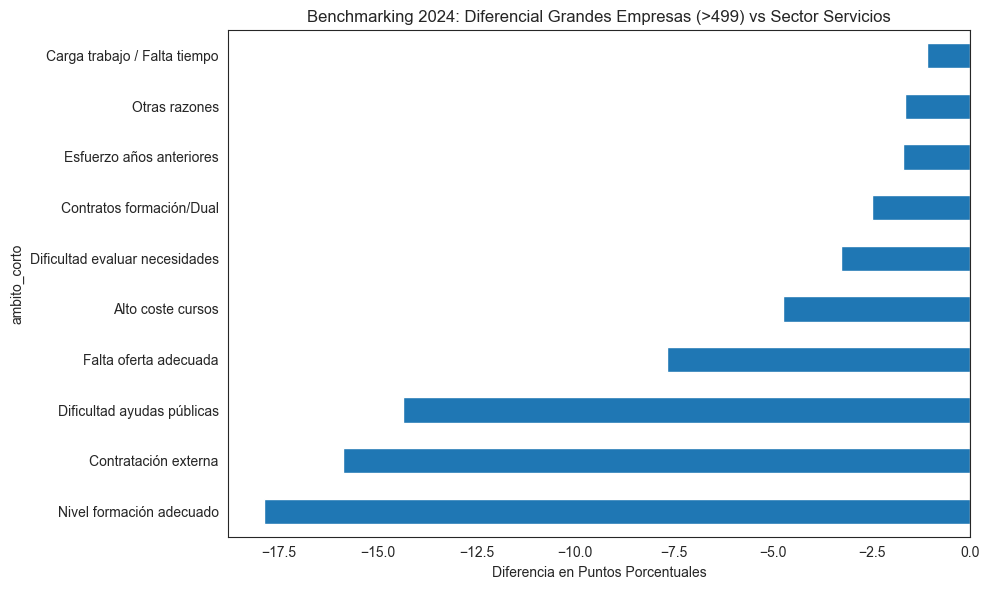

In [162]:
fig, ax = plt.subplots(figsize=(10,6), facecolor='none')
ax.set_facecolor('none')

comparativa_2024['Diferencia_pp'].sort_values().plot(
    kind='barh', 
    ax=ax
)

plt.title('Benchmarking 2024: Diferencial Grandes Empresas (>499) vs Sector Servicios')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Diferencia en Puntos Porcentuales')

plt.tight_layout()
plt.show()

> El análisis comparativo muestra que las empresas de más de 499 trabajadores perciben **menos barreras para la formación que la media de servicios**. Sin embargo, también son **menos propensas a considerar que el nivel formativo de su plantilla ya es suficiente**, lo que sugiere una mayor orientación hacia el desarrollo continuo de competencias y una mayor exigencia en materia de formación.

#### Validación Estadistica

Basándonos en el Informe Metodológico, los tamaños de muestra (n) para el año 2024 son:
- Grandes Empresas (>499 trabajadores): n=1.992 empresas.
- Sector Servicios (Total): n=5.963 empresas (suma de los subsectores G a S del informe).

In [163]:
# 1. Parámetros de muestra para 2024
n_499 = 1992
n_servicios = 5963

# 2. Filtramos solo 2024
df_2024 = df_relevancia[df_relevancia['anio'] == 2024].copy()

barreras = (
    df_2024[df_2024['tabla'] == 'EAL-24c']['ambito_corto']
    .unique()
)

resultados = []

for barrera in barreras:

    fila_499 = df_2024[
        (df_2024['tabla'] == 'EAL-24c') &
        (df_2024['ambito_corto'] == barrera)
    ]

    fila_servicios = df_2024[
        (df_2024['tabla'] == 'EAL-24f') &
        (df_2024['ambito_corto'] == barrera)
    ]

    # Saltamos si falta alguna observación
    if fila_499.empty or fila_servicios.empty:
        continue

    # Extraemos valores escalares
    p1 = float(fila_499['RELEVANCIA'].iloc[0])
    p2 = float(fila_servicios['RELEVANCIA'].iloc[0])

    # Conversión a frecuencias absolutas
    count = [
        round(p1 * n_499 / 100),
        round(p2 * n_servicios / 100)
    ]

    nobs = [n_499, n_servicios]

    # Z-test de proporciones
    stat, p_value = proportions_ztest(count, nobs)

    resultados.append({
        'Barrera': barrera,
        'Relevancia >499 (%)': round(p1, 2),
        'Relevancia Servicios (%)': round(p2, 2),
        'Diferencia (pp)': round(p1 - p2, 2),
        'p-valor': round(p_value, 4),
        'Significativa (p<0.05)': 'SÍ' if p_value < 0.05 else 'NO'
    })

# 3. Resultados
df_ztest = pd.DataFrame(resultados)

df_ztest = df_ztest.sort_values(
    by='Diferencia (pp)',
    key=lambda x: abs(x),
    ascending=False
)

print("\n--- VALIDACIÓN ESTADÍSTICA: GRANDES EMPRESAS VS SECTOR SERVICIOS (2024) ---\n")
print(df_ztest)


--- VALIDACIÓN ESTADÍSTICA: GRANDES EMPRESAS VS SECTOR SERVICIOS (2024) ---

                          Barrera  Relevancia >499 (%)  \
0        Nivel formación adecuado                53.29   
1            Contratación externa                37.75   
8      Dificultad ayudas públicas                23.05   
3           Falta oferta adecuada                19.89   
4               Alto coste cursos                37.57   
2  Dificultad evaluar necesidades                13.50   
5        Contratos formación/Dual                 5.56   
6        Esfuerzo años anteriores                21.78   
9                   Otras razones                 7.47   
7    Carga trabajo / Falta tiempo                55.06   

   Relevancia Servicios (%)  Diferencia (pp)  p-valor Significativa (p<0.05)  
0                     71.18           -17.89   0.0000                     SÍ  
1                     53.63           -15.88   0.0000                     SÍ  
8                     37.40           -14.35  

Los resultados muestran que, en la mayoría de las barreras analizadas, existen diferencias estadísticamente significativas entre las grandes empresas formadoras (>499 empleados) y el conjunto formador del sector servicios, lo que indica que ambos grupos no perciben los obstáculos a la formación de la misma manera.

"Nivel de formación apropiado" tiene un p-valor de 0.0000 --> las grandes empresas son mucho más exigentes y autocríticas con sus competencias que las empresas más pequeñas de servicios.